# 04 - Treino LSTM (PyTorch)

LSTM bidirecional com pooling (attention, mean, last).

- **Dataset**: `data/processed/dataset_combined.csv`
- **Validações**: `dataset-exemplos.csv` e `subm1_labels_revealed.csv`
- **Método**: Random search com 20 iterações

In [3]:
import sys
import os
sys.path.append(os.path.abspath('..'))

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import random
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    roc_curve, auc
)

from sklearn.preprocessing import label_binarize

from src.data_processing import clean_text
from src.features import Vocabulary, texts_to_sequences, TextDataset
from src.models_pytorch.lstm import LSTMClassifier

In [5]:
# Configuração
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cpu


## 1. Carregamento de Dados

In [6]:
# Constantes
ROOT = os.path.abspath('..')
CLASSES = ['Anthropic', 'Google', 'Human', 'Meta', 'OpenAI']
LABEL_MAP = {label: i for i, label in enumerate(CLASSES)}
IDX_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}
NUM_CLASSES = len(CLASSES)

TRAIN_PATH = os.path.join(ROOT, 'data', 'processed', 'dataset_combined.csv')
VAL1_PATH = os.path.join(ROOT, 'data', 'validation', 'dataset-exemplos.csv')
VAL2_PATH = os.path.join(ROOT, 'data', 'validation', 'subm1_labels_revealed.csv')

print(f'Classes: {LABEL_MAP}')

Classes: {'Anthropic': 0, 'Google': 1, 'Human': 2, 'Meta': 3, 'OpenAI': 4}


In [7]:
def load_data(path):
    df = pd.read_csv(path, sep=';')
    df = df[df['Label'].isin(CLASSES)].copy()
    df['label_id'] = df['Label'].map(LABEL_MAP)
    df['text_clean'] = df['Text'].apply(clean_text)
    return df

df_train = load_data(TRAIN_PATH)
df_val1 = load_data(VAL1_PATH)
df_val2 = load_data(VAL2_PATH)

print(f'Train: {len(df_train)} amostras')
print(f'  Labels: {df_train["Label"].value_counts().to_dict()}')
print(f'Val1 (exemplos): {len(df_val1)} amostras')
print(f'Val2 (subm1): {len(df_val2)} amostras')

Train: 2195 amostras
  Labels: {'Anthropic': 500, 'OpenAI': 481, 'Google': 480, 'Meta': 480, 'Human': 254}
Val1 (exemplos): 125 amostras
Val2 (subm1): 100 amostras


## 2. Funções de Treino

In [8]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for seqs, labs in loader:
        seqs, labs = seqs.to(device), labs.to(device)
        optimizer.zero_grad()
        out = model(seqs)
        loss = criterion(out, labs)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * len(labs)
        correct += (out.argmax(dim=1) == labs).sum().item()
        total += len(labs)
    return total_loss / total, correct / total

def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for seqs, labs in loader:
            seqs, labs = seqs.to(device), labs.to(device)
            out = model(seqs)
            loss = criterion(out, labs)
            total_loss += loss.item() * len(labs)
            correct += (out.argmax(dim=1) == labs).sum().item()
            total += len(labs)
    return total_loss / total, correct / total

def train_lstm(params, X_train_seq, y_train, X_val_seq, y_val, vocab_size, device):
    model = LSTMClassifier(
        vocab_size=vocab_size,
        embedding_dim=params['embedding_dim'],
        hidden_dim=params['hidden_dim'],
        output_dim=NUM_CLASSES,
        n_layers=params['n_layers'],
        dropout=params['dropout'],
        pooling=params['pooling'],
    ).to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'])
    
    train_ds = TextDataset(X_train_seq, y_train)
    val_ds = TextDataset(X_val_seq, y_val)
    train_dl = DataLoader(train_ds, batch_size=params['batch_size'], shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=params['batch_size'])
    
    best_val_acc = 0
    patience_counter = 0
    best_state = None
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    t0 = time.time()
    for epoch in range(params['epochs']):
        tr_loss, tr_acc = train_epoch(model, train_dl, optimizer, criterion, device)
        vl_loss, vl_acc = eval_epoch(model, val_dl, criterion, device)
        
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)
        
        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 10:
                break
    
    train_time = time.time() - t0
    model.load_state_dict(best_state)
    
    return model, best_val_acc, max(history['train_acc']), history, train_time

def evaluate_external_lstm(model, X_seq, y_labels, batch_size, device):
    ds = TextDataset(X_seq, y_labels)
    dl = DataLoader(ds, batch_size=batch_size)
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for seqs, labs in dl:
            seqs, labs = seqs.to(device), labs.to(device)
            out = model(seqs)
            correct += (out.argmax(dim=1) == labs).sum().item()
            total += len(labs)
    return correct / total

## 3. Param Grid e Random Search

In [9]:
param_grid = {
    'hidden_dim': [64, 128, 256],
    'n_layers': [1, 2],
    'dropout': [0.3, 0.5],
    'pooling': ['attention', 'mean', 'last'],
    'embedding_dim': [50, 100],
    'lr': [0.001, 0.005],
    'batch_size': [32, 64],
    'epochs': [30, 50],
}

print('Opções por parâmetro:')
for k, v in param_grid.items():
    print(f'  {k}: {len(v)} opções')

Opções por parâmetro:
  hidden_dim: 3 opções
  n_layers: 2 opções
  dropout: 2 opções
  pooling: 3 opções
  embedding_dim: 2 opções
  lr: 2 opções
  batch_size: 2 opções
  epochs: 2 opções


In [10]:
SEED = 42
N_ITERATIONS = 20
MAX_LEN = 150
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Preparar vocabulário e sequências
print('Construindo vocabulário...')
vocab = Vocabulary(max_words=5000)
vocab.fit(list(df_train['text_clean']))
print(f'Vocabulário: {len(vocab)} palavras')

# Sequências de treino
X_train_seq = texts_to_sequences(list(df_train['text_clean']), vocab, max_len=MAX_LEN)
y_train = df_train['label_id'].values.astype(np.int64)

# Split train/val interno
X_tr, X_te, y_tr, y_te = train_test_split(
    X_train_seq, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Sequências de validação externa
X_val1_seq = texts_to_sequences(list(df_val1['text_clean']), vocab, max_len=MAX_LEN)
y_val1 = df_val1['label_id'].values.astype(np.int64)

X_val2_seq = texts_to_sequences(list(df_val2['text_clean']), vocab, max_len=MAX_LEN)
y_val2 = df_val2['label_id'].values.astype(np.int64)

print(f'Train interno: {len(X_tr)}, Val interno: {len(X_te)}')
print(f'Val1 externo: {len(X_val1_seq)}, Val2 externo: {len(X_val2_seq)}')

Construindo vocabulário...
Vocabulário: 5002 palavras
Train interno: 1756, Val interno: 439
Val1 externo: 125, Val2 externo: 100


In [11]:
def sample_params(grid, rng):
    return {k: rng.choice(v) for k, v in grid.items()}

In [12]:
results = []
best_val1_acc = -1
best_model = None
best_params = None

print(f'=== Random Search: LSTM — {N_ITERATIONS} iterações ===')
print()

for i in range(N_ITERATIONS):
    params = sample_params(param_grid, random)
    
    print(f"[{i+1}/{N_ITERATIONS}] h={params['hidden_dim']} "
          f"layers={params['n_layers']} pool={params['pooling']} "
          f"emb={params['embedding_dim']} lr={params['lr']} "
          f"bs={params['batch_size']} epochs={params['epochs']}")
    
    try:
        model, val_acc, train_acc, history, train_time = train_lstm(
            params, X_tr, y_tr, X_te, y_te, len(vocab), DEVICE
        )
        
        val1_acc = evaluate_external_lstm(model, X_val1_seq, y_val1, 
                                          params['batch_size'], DEVICE)
        val2_acc = evaluate_external_lstm(model, X_val2_seq, y_val2,
                                          params['batch_size'], DEVICE)
        
        print(f"  -> internal={val_acc:.4f} | val1={val1_acc:.4f} | val2={val2_acc:.4f} ({train_time:.1f}s)")
        
        results.append({
            'iteration': i + 1,
            'hidden_dim': params['hidden_dim'],
            'n_layers': params['n_layers'],
            'dropout': params['dropout'],
            'pooling': params['pooling'],
            'embedding_dim': params['embedding_dim'],
            'lr': params['lr'],
            'batch_size': params['batch_size'],
            'epochs': params['epochs'],
            'internal_val': val_acc,
            'train_acc': train_acc,
            'val1_acc': val1_acc,
            'val2_acc': val2_acc,
            'train_time': train_time,
        })
        
        if val1_acc > best_val1_acc:
            best_val1_acc = val1_acc
            best_model = model
            best_params = params.copy()
            print(f"  *** NOVO MELHOR ***")
    
    except Exception as e:
        print(f"  -> ERRO: {e}")
        results.append({
            'iteration': i + 1,
            'error': str(e),
            **params
        })

print(f'\n=== Concluído ===')

=== Random Search: LSTM — 20 iterações ===

[1/20] h=256 layers=1 pool=last emb=100 lr=0.001 bs=32 epochs=30
  -> internal=0.6856 | val1=0.3440 | val2=0.3900 (62.5s)
  *** NOVO MELHOR ***
[2/20] h=256 layers=1 pool=last emb=100 lr=0.001 bs=32 epochs=30
  -> internal=0.6743 | val1=0.3840 | val2=0.2900 (62.4s)
  *** NOVO MELHOR ***
[3/20] h=64 layers=1 pool=last emb=50 lr=0.005 bs=32 epochs=50
  -> internal=0.6856 | val1=0.3280 | val2=0.2800 (19.3s)
[4/20] h=256 layers=2 pool=attention emb=100 lr=0.005 bs=64 epochs=30
  -> internal=0.7859 | val1=0.4720 | val2=0.3900 (165.4s)
  *** NOVO MELHOR ***
[5/20] h=64 layers=2 pool=attention emb=100 lr=0.001 bs=64 epochs=50
  -> internal=0.7358 | val1=0.4080 | val2=0.3700 (24.3s)
[6/20] h=256 layers=2 pool=last emb=100 lr=0.001 bs=64 epochs=30
  -> internal=0.7221 | val1=0.3760 | val2=0.3200 (175.7s)
[7/20] h=256 layers=2 pool=last emb=50 lr=0.001 bs=32 epochs=30
  -> internal=0.6515 | val1=0.3600 | val2=0.2900 (116.0s)
[8/20] h=128 layers=1 pool=

## 4. Resultados

In [13]:
results_df = pd.DataFrame(results)
if 'error' in results_df.columns:
    results_df = results_df[results_df['error'].isna()]

if 'val1_acc' in results_df.columns and len(results_df) > 0:
    print('=== Top 5 Modelos (por val1_acc) ===')
    print()
    top5 = results_df.nlargest(5, 'val1_acc')[
        ['iteration', 'hidden_dim', 'n_layers', 'pooling', 'dropout',
         'lr', 'internal_val', 'val1_acc', 'val2_acc']
    ]
    print(top5.to_string(index=False))
    
    print('\n=== Top 5 Modelos (por val2_acc) ===')
    print()
    top5_val2 = results_df.nlargest(5, 'val2_acc')[
        ['iteration', 'hidden_dim', 'n_layers', 'pooling', 'dropout',
         'lr', 'internal_val', 'val1_acc', 'val2_acc']
    ]
    print(top5_val2.to_string(index=False))

=== Top 5 Modelos (por val1_acc) ===

 iteration  hidden_dim  n_layers   pooling  dropout    lr  internal_val  val1_acc  val2_acc
         4         256         2 attention      0.3 0.005      0.785877     0.472      0.39
        15         256         1      mean      0.5 0.005      0.815490     0.440      0.31
        16         256         2 attention      0.5 0.005      0.767654     0.432      0.33
         5          64         2 attention      0.3 0.001      0.735763     0.408      0.37
         2         256         1      last      0.3 0.001      0.674260     0.384      0.29

=== Top 5 Modelos (por val2_acc) ===

 iteration  hidden_dim  n_layers   pooling  dropout    lr  internal_val  val1_acc  val2_acc
         1         256         1      last      0.3 0.001      0.685649     0.344      0.39
         4         256         2 attention      0.3 0.005      0.785877     0.472      0.39
         5          64         2 attention      0.3 0.001      0.735763     0.408      0.37
   

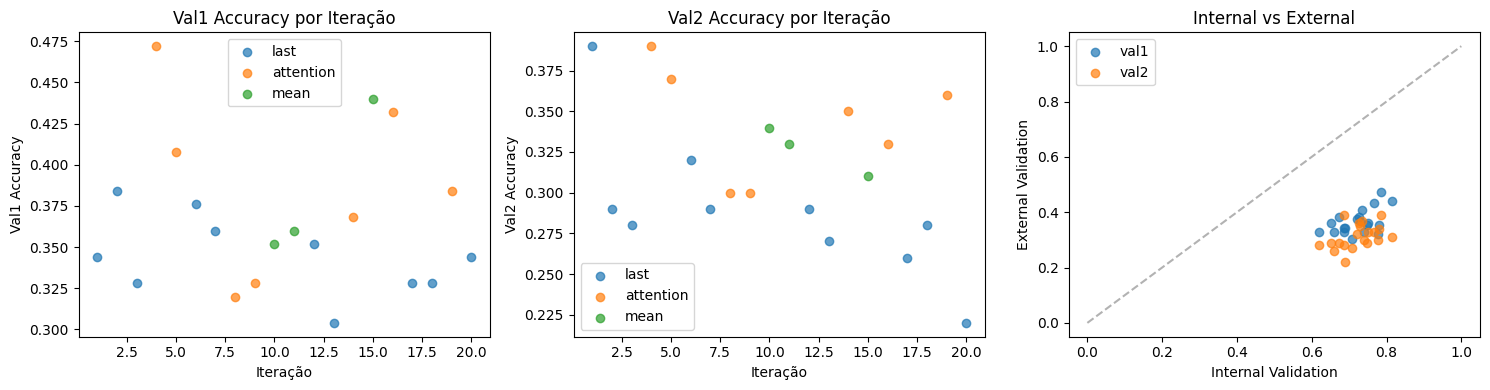

In [14]:
# Visualização
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Val1 accuracy por pooling
for pool in results_df['pooling'].unique():
    mask = results_df['pooling'] == pool
    axes[0].scatter(results_df[mask]['iteration'], results_df[mask]['val1_acc'],
                   label=pool, alpha=0.7)
axes[0].set_xlabel('Iteração')
axes[0].set_ylabel('Val1 Accuracy')
axes[0].set_title('Val1 Accuracy por Iteração')
axes[0].legend()

# Val2 accuracy por pooling
for pool in results_df['pooling'].unique():
    mask = results_df['pooling'] == pool
    axes[1].scatter(results_df[mask]['iteration'], results_df[mask]['val2_acc'],
                   label=pool, alpha=0.7)
axes[1].set_xlabel('Iteração')
axes[1].set_ylabel('Val2 Accuracy')
axes[1].set_title('Val2 Accuracy por Iteração')
axes[1].legend()

# Internal vs External
axes[2].scatter(results_df['internal_val'], results_df['val1_acc'],
               label='val1', alpha=0.7)
axes[2].scatter(results_df['internal_val'], results_df['val2_acc'],
               label='val2', alpha=0.7)
axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[2].set_xlabel('Internal Validation')
axes[2].set_ylabel('External Validation')
axes[2].set_title('Internal vs External')
axes[2].legend()

plt.tight_layout()
plt.show()

## 5. Avaliação Detalhada do Melhor Modelo

In [15]:
print('=== Melhor Modelo LSTM ===')
print(f"Hidden dim: {best_params['hidden_dim']}")
print(f"Layers: {best_params['n_layers']}")
print(f"Pooling: {best_params['pooling']}")
print(f"Dropout: {best_params['dropout']}")
print(f"Embedding dim: {best_params['embedding_dim']}")
print(f"LR: {best_params['lr']}")
print(f"Batch size: {best_params['batch_size']}")
print(f"Epochs: {best_params['epochs']}")

=== Melhor Modelo LSTM ===
Hidden dim: 256
Layers: 2
Pooling: attention
Dropout: 0.3
Embedding dim: 100
LR: 0.005
Batch size: 64
Epochs: 30


In [16]:
def get_predictions_lstm(model, X_seq, y_labels, batch_size, device):
    """Obtém predições e probabilidades."""
    ds = TextDataset(X_seq, y_labels)
    dl = DataLoader(ds, batch_size=batch_size)
    model.eval()
    all_probs = []
    all_labels = []
    with torch.no_grad():
        for seqs, labs in dl:
            seqs = seqs.to(device)
            out = model(seqs)
            probs = torch.softmax(out, dim=1).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(labs.numpy())
    return np.vstack(all_probs), np.concatenate(all_labels)

def full_evaluation_lstm(model, X_seq, y_labels, name, batch_size, device):
    """Avaliação completa."""
    probs, labels = get_predictions_lstm(model, X_seq, y_labels, batch_size, device)
    preds = np.argmax(probs, axis=1)
    
    acc = accuracy_score(labels, preds)
    
    print(f'\n=== {name} ===')
    print(f'Accuracy: {acc:.4f}')
    print()
    print(classification_report(labels, preds, target_names=CLASSES, zero_division=0))
    
    # Matriz de confusão
    fig, ax = plt.subplots(figsize=(8, 6))
    cm = confusion_matrix(labels, preds)
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.figure.colorbar(im, ax=ax)
    ax.set(
        xticks=np.arange(NUM_CLASSES),
        yticks=np.arange(NUM_CLASSES),
        xticklabels=CLASSES,
        yticklabels=CLASSES,
        ylabel='Real',
        xlabel='Previsto',
        title=f'Matriz de Confusão — {name}',
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black')
    
    plt.tight_layout()
    plt.show()
    
    return probs, labels


=== Val1 (exemplos) ===
Accuracy: 0.4720

              precision    recall  f1-score   support

   Anthropic       0.38      0.35      0.36        23
      Google       0.23      0.38      0.29        16
       Human       0.57      0.75      0.64        52
        Meta       1.00      0.12      0.21        17
      OpenAI       0.57      0.24      0.33        17

    accuracy                           0.47       125
   macro avg       0.55      0.37      0.37       125
weighted avg       0.55      0.47      0.45       125



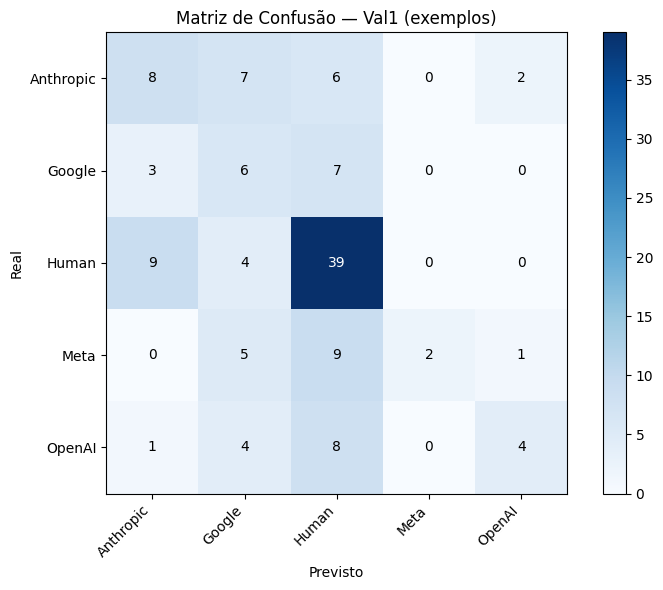


=== Val2 (subm1) ===
Accuracy: 0.3900

              precision    recall  f1-score   support

   Anthropic       0.30      0.41      0.35        17
      Google       0.30      0.18      0.22        17
       Human       0.42      0.74      0.53        34
        Meta       1.00      0.22      0.36        18
      OpenAI       0.00      0.00      0.00        14

    accuracy                           0.39       100
   macro avg       0.40      0.31      0.29       100
weighted avg       0.42      0.39      0.34       100



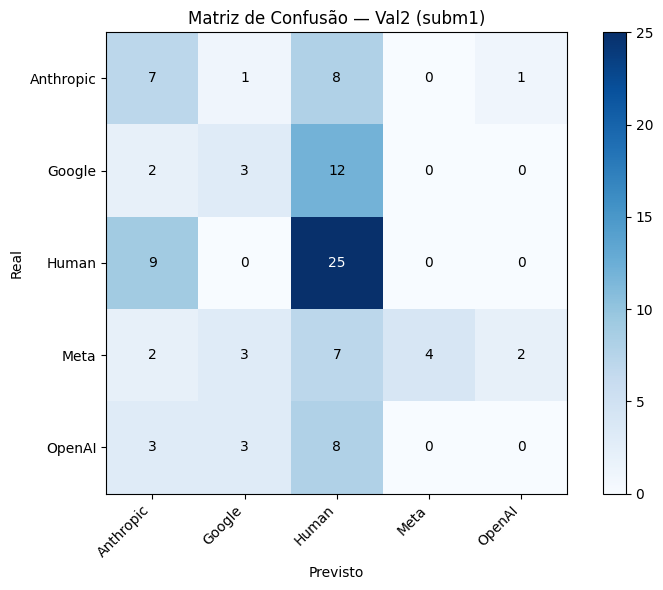

In [17]:
probs_val1, labels_val1 = full_evaluation_lstm(
    best_model, X_val1_seq, y_val1, 'Val1 (exemplos)', 
    best_params['batch_size'], DEVICE
)
probs_val2, labels_val2 = full_evaluation_lstm(
    best_model, X_val2_seq, y_val2, 'Val2 (subm1)',
    best_params['batch_size'], DEVICE
)

## 6. Curva ROC (Macro Average)

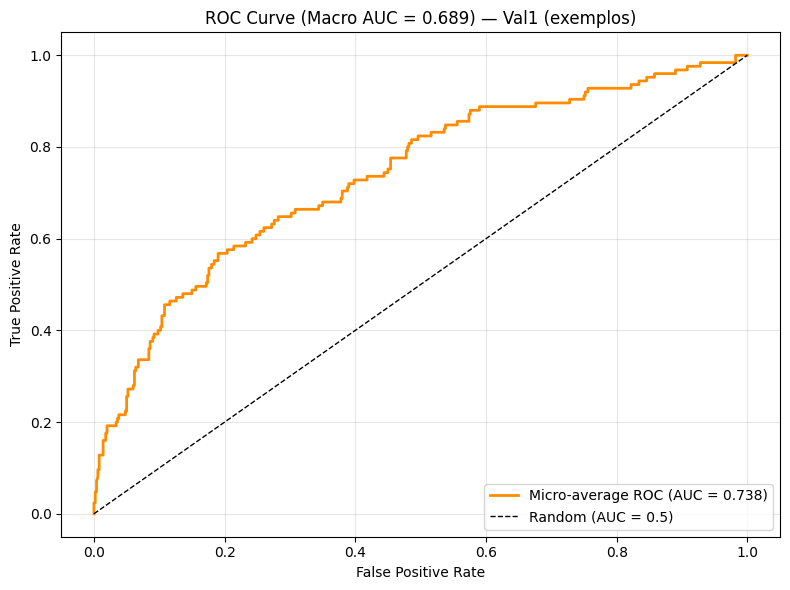

Val1 (exemplos): Micro AUC = 0.7379, Macro AUC = 0.6894


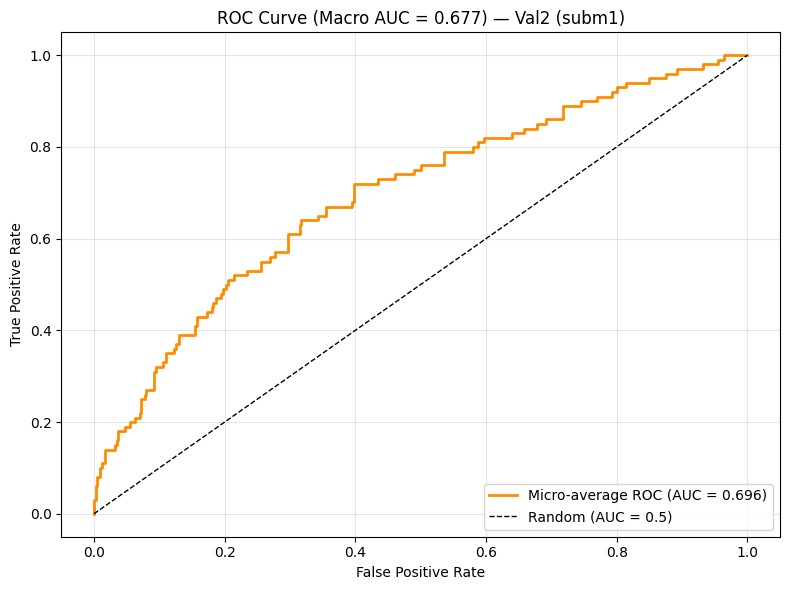

Val2 (subm1): Micro AUC = 0.6955, Macro AUC = 0.6767


In [18]:
def plot_roc_macro(probs, labels, name):
    labels_bin = label_binarize(labels, classes=range(NUM_CLASSES))
    
    fpr, tpr, _ = roc_curve(labels_bin.ravel(), probs.ravel())
    roc_auc = auc(fpr, tpr)
    
    aucs = []
    for i in range(NUM_CLASSES):
        fpr_i, tpr_i, _ = roc_curve(labels_bin[:, i], probs[:, i])
        aucs.append(auc(fpr_i, tpr_i))
    macro_auc = np.mean(aucs)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'Micro-average ROC (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.5)')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve (Macro AUC = {macro_auc:.3f}) — {name}')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f'{name}: Micro AUC = {roc_auc:.4f}, Macro AUC = {macro_auc:.4f}')
    return macro_auc

macro_auc_val1 = plot_roc_macro(probs_val1, labels_val1, 'Val1 (exemplos)')
macro_auc_val2 = plot_roc_macro(probs_val2, labels_val2, 'Val2 (subm1)')

## 7. Conclusões

In [19]:
print('=' * 60)
print('CONCLUSÕES — LSTM')
print('=' * 60)
print()

print('Média por pooling:')
for pool in results_df['pooling'].unique():
    mask = results_df['pooling'] == pool
    mean_v1 = results_df[mask]['val1_acc'].mean()
    mean_v2 = results_df[mask]['val2_acc'].mean()
    print(f'  {pool:10s}: val1={mean_v1:.4f} | val2={mean_v2:.4f}')

print()
print('Melhor configuração:')
print(f"  Hidden dim: {best_params['hidden_dim']}")
print(f"  Layers: {best_params['n_layers']}")
print(f"  Pooling: {best_params['pooling']}")
print(f"  Dropout: {best_params['dropout']}")
print(f"  Embedding: {best_params['embedding_dim']}")
print(f"  LR: {best_params['lr']}")
print()
print(f'Val1 Accuracy: {best_val1_acc:.4f}')
print(f'Val1 AUC (macro): {macro_auc_val1:.4f}')
best_val2 = results_df.loc[results_df['val1_acc'].idxmax(), 'val2_acc']
print(f'Val2 Accuracy: {best_val2:.4f}')
print(f'Val2 AUC (macro): {macro_auc_val2:.4f}')

CONCLUSÕES — LSTM

Média por pooling:
  last      : val1=0.3448 | val2=0.2890
  attention : val1=0.3874 | val2=0.3429
  mean      : val1=0.3840 | val2=0.3267

Melhor configuração:
  Hidden dim: 256
  Layers: 2
  Pooling: attention
  Dropout: 0.3
  Embedding: 100
  LR: 0.005

Val1 Accuracy: 0.4720
Val1 AUC (macro): 0.6894
Val2 Accuracy: 0.3900
Val2 AUC (macro): 0.6767


In [20]:
# Guardar resultados
results_path = os.path.join(ROOT, 'data', 'processed', 'lstm_results.csv')
results_df.to_csv(results_path, index=False)
print(f'Resultados guardados em {results_path}')

Resultados guardados em /home/joaocunha50/studys/university/MEI/1_ano/2_sem/AP/Projeto-AP/data/processed/lstm_results.csv
